# TP3 --- Transformée de Fourier

**Ce notebook est un compagnon d'exécution, pas le sujet.** Le sujet de
référence -- questions complètes, contexte, rappels -- est **`TP3.pdf`**.
Gardez-le ouvert à côté : les cellules ci-dessous sont repérées par leur
numéro de question dans le PDF (A1, A2, B1, ...) et n'en reprennent que
l'essentiel.

Vos réponses vont sur **feuille**.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tp3_helpers import (
    make_door, make_beat, explorer,
    fourier_transform, spectrum, inverse_fourier_transform,
    plot_signal, plot_spectrum, plot_reconstruction,
)

## A --- Valeur moyenne et exponentielle complexe

### A1 : sur papier

### A2 : porte, valeur moyenne en cosinus et en sinus

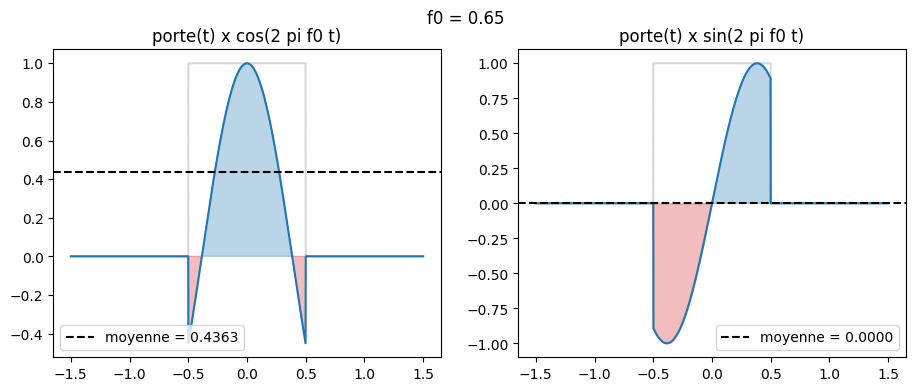

valeur théorique (formule de A1) : 0.4363
valeur numérique (moyenne en cosinus) : 0.4363


In [10]:
explorer(f0=0.65, theta=1.0, A=1.0)

### A3 : tracer le spectre point par point

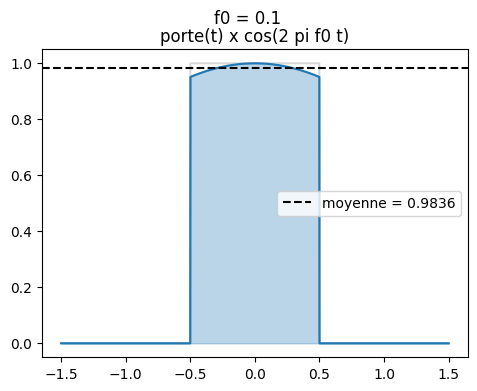

valeur théorique (formule de A1) : 0.9836
valeur numérique (moyenne en cosinus) : 0.9836


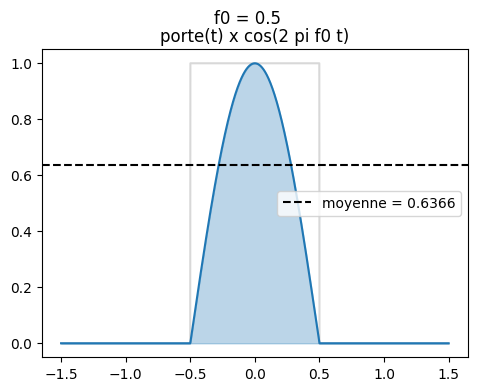

valeur théorique (formule de A1) : 0.6366
valeur numérique (moyenne en cosinus) : 0.6366


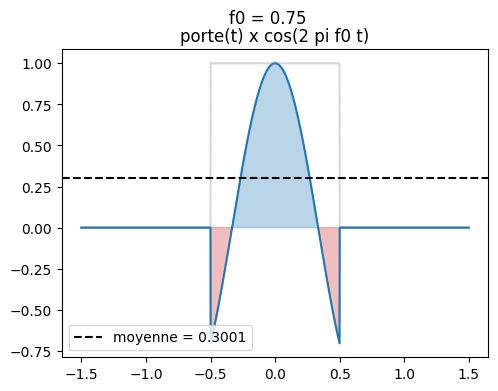

valeur théorique (formule de A1) : 0.3001
valeur numérique (moyenne en cosinus) : 0.3001


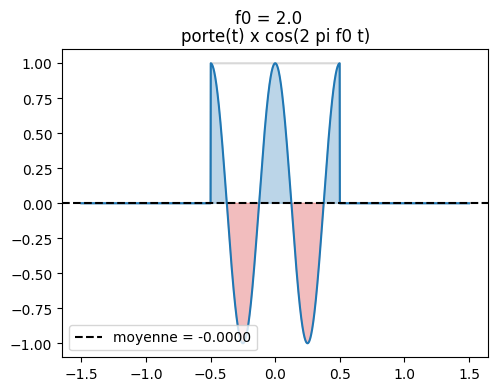

valeur théorique (formule de A1) : -0.0000
valeur numérique (moyenne en cosinus) : -0.0000


In [14]:
for f0 in [0.1, 0.5, 0.75, 2.0]:  # <- les quatre valeurs demandées
    explorer(f0, montrer_sin=False)

## B --- La transformée de Fourier

### B1 : sur papier

### B2 : spectre de la porte, plusieurs largeurs

/var/folders/w2/zsb3q_6x4q10bl6s9ggbb26m0000gn/T/ipykernel_51125/2800891893.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


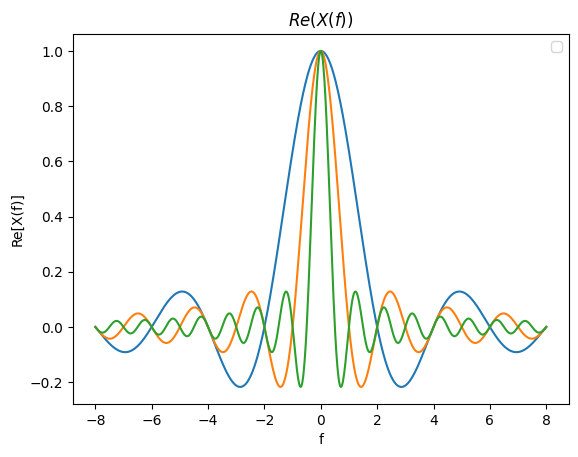

In [ ]:
freqs = np.linspace(-8, 8, 800)
for theta in [0.5, 1.0, 2.0]:  # <- modifiez ces largeurs et ré-exécutez
    k = make_door(theta=theta, A=1/theta)
    X = spectrum(k, freqs)
    plot_spectrum(freqs, X, kind="re", title="$Re(X(f))$")
    # plot_spectrum(freqs, X, kind="im", title="$Im(X(f))$")
    # plot_spectrum(freqs, X, kind="abs", title="$\vert (X(f)) \vert$")

plt.legend()
plt.xlabel("f")
plt.show()

### B3 : porte rétrécie, aire conservée

/var/folders/w2/zsb3q_6x4q10bl6s9ggbb26m0000gn/T/ipykernel_51125/1475190756.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


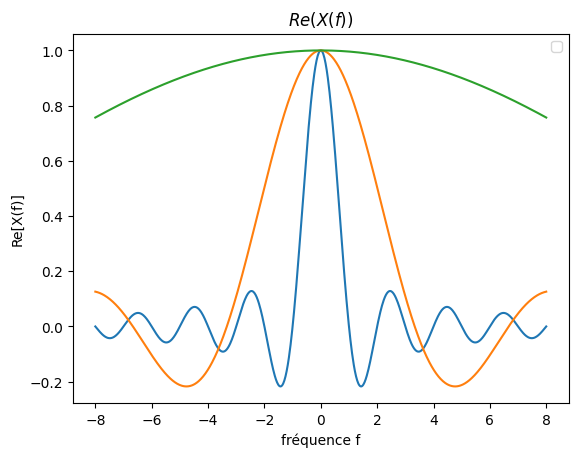

In [28]:
freqs = np.linspace(-8, 8, 800)
for theta in [1.0, 0.3, 0.05]:  # <- modifiez ces largeurs et ré-exécutez
    p = make_door(theta=theta, A=1.0 / theta)  # aire = 1, cf. impulsion de Dirac
    X = spectrum(p, freqs)
    plot_spectrum(freqs, X, kind="re", title="$Re(X(f))$")

plt.legend()
plt.show()

### B4 : sur papier

### B5 : sur papier

### B6 : troncature fréquentielle, reconstruction

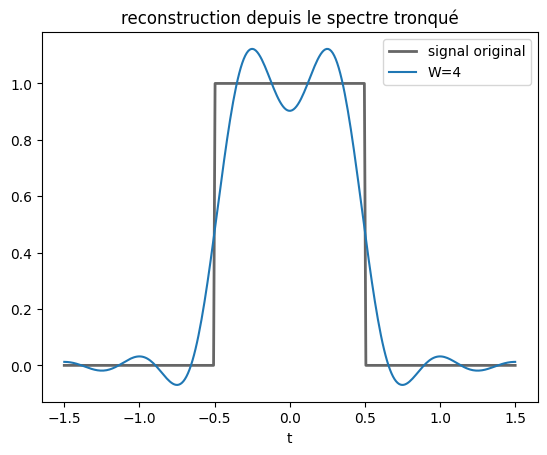

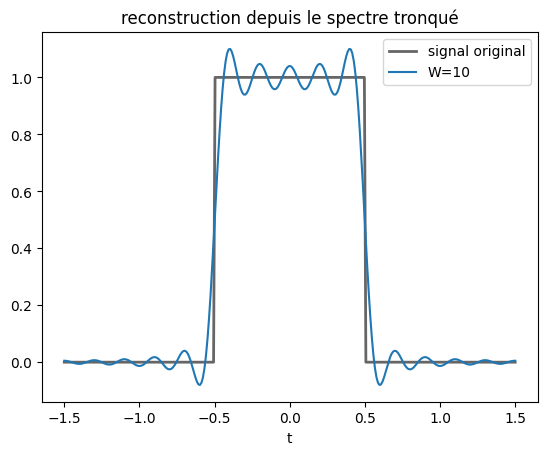

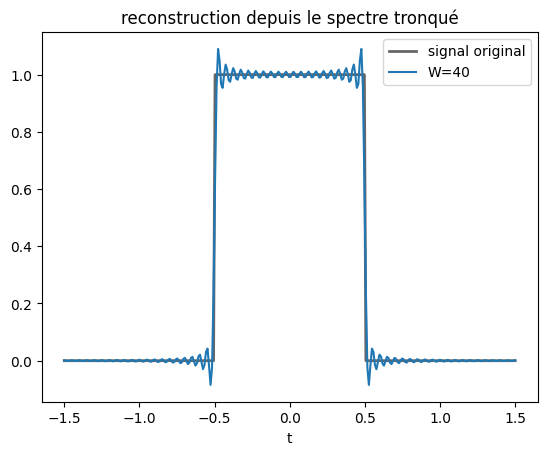

In [29]:
theta = 1.0
porte = make_door(theta=theta, A=1.0)


def sinc(x):
    return 1.0 if x == 0 else np.sin(x) / x


def X_theorique(f):
    # X(f) de la porte, formule de B1
    return complex(theta * sinc(np.pi * f * theta), 0.0)


def X_tronque(f, W):
    return X_theorique(f) if abs(f) < W / 2 else 0j


t = np.linspace(-1.5, 1.5, 300)
original = [porte.f(ti) for ti in t]

for W in [4, 10, 40]:  # <- modifiez ces largeurs de bande et ré-exécutez
    y = [inverse_fourier_transform(lambda f: X_tronque(f, W), ti, -W / 2, W / 2)
         for ti in t]
    plot_reconstruction(t, {f"W={W}": y}, original=original,
                         title="reconstruction depuis le spectre tronqué")
    plt.show()

## C --- Résolution fréquentielle

### C1 : le signal, durée courte

In [ ]:
f1, f2, T = 1.0, 1.2, 3.0  # <- changez T (et ré-exécutez C1, C2)
beat = make_beat(f1, f2, T)
plot_signal(beat, tmin=-T / 2, tmax=T / 2, npts=2000)
plt.show()

### C2 : spectre, durée courte

In [ ]:
freqs = np.linspace(0.7, 1.5, 400)
X = spectrum(beat, freqs)
plot_spectrum(freqs, X, title=f"Spectre, T={T}")
plt.show()

### C3 : durée longue

In [ ]:
T = 8.0  # <- changez T (et ré-exécutez cette cellule)
beat = make_beat(f1, f2, T)
plot_signal(beat, tmin=-T / 2, tmax=T / 2, npts=2000)
plt.show()

freqs = np.linspace(0.7, 1.5, 400)
X = spectrum(beat, freqs)
plot_spectrum(freqs, X, title=f"Spectre, T={T}")
plt.show()

### C4 : comparer plusieurs durées

In [ ]:
freqs = np.linspace(0.7, 1.5, 400)
for T in [3, 5, 8, 15]:  # <- durées d'observation à comparer
    beat = make_beat(f1, f2, T)
    X = spectrum(beat, freqs)
    plot_spectrum(freqs, X, title=f"T = {T}")
    plt.show()

### C5 : sur papier